In [ ]:
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
import os
import random
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

save_dir = "/content/drive/MyDrive/fer_emotion"
os.makedirs(save_dir, exist_ok=True)  # create if not exists

save_path = os.path.join(save_dir, "checkpoint.pth")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub

# Download latest version
base_path = kagglehub.dataset_download("subhaditya/fer2013plus")

print("Path to dataset files:", base_path)

Using Colab cache for faster access to the 'fer2013plus' dataset.
Path to dataset files: /kaggle/input/fer2013plus


In [ ]:
import os
import random

# Collect all image paths from the 'anger' class
image_paths = []
for root, _, files in os.walk(f"{base_path}/fer2013plus/fer2013/train/anger"):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

# Check and safely sample
if len(image_paths) < 3:
    print(f"Only {len(image_paths)} image(s) found.")
    random_images = image_paths
else:
    random_images = random.sample(image_paths, 3)

# Print the sampled image paths
for img in random_images:
    print(img)


/kaggle/input/fer2013plus/fer2013plus/fer2013/train/anger/fer0013809.png
/kaggle/input/fer2013plus/fer2013plus/fer2013/train/anger/fer0022304.png
/kaggle/input/fer2013plus/fer2013plus/fer2013/train/anger/fer0016244.png


In [ ]:
import cv2
import numpy as np
import torch

def apply_grayscale_rgb(image):
    """
    Convert RGB image to grayscale and back to 3-channel for CNN.
    Expects image in uint8 [0,255] format.
    Returns float32 tensor normalized to [-1,1], shape [3,H,W].
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    tensor = torch.from_numpy(gray_rgb).float().permute(2,0,1)  # [C,H,W]
    tensor = (tensor / 255.0 - 0.5) / 0.5  # normalize to [-1,1]
    return tensor

def apply_canny_rgb(image):
    """
    Apply proper Canny edge detection with Gaussian blur.
    Returns 3-channel float32 tensor normalized to [-1,1], shape [3,H,W].
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3,3), 0)
    edges = cv2.Canny(blurred, 80, 160)  # same thresholds as training
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    tensor = torch.from_numpy(edges_rgb).float().permute(2,0,1)
    tensor = (tensor / 255.0 - 0.5) / 0.5
    return tensor


In [ ]:
class FERPlusGrayCannyDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.image_paths, self.labels = [], []

        for cls_name in self.classes:
            cls_folder = os.path.join(root_dir, cls_name)
            for img_file in os.listdir(cls_folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(cls_folder, img_file))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        image = cv2.imread(path)  # BGR
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        filters_to_apply = [apply_grayscale_rgb, apply_canny_rgb]
        all_views = []

        for func in filters_to_apply:
            filtered = func(image)  # returns tensor [C,H,W] normalized [-1,1]
            # convert back to NumPy array in HWC format for transforms
            filtered_np = (filtered.permute(1,2,0).numpy() * 0.5 + 0.5) * 255  # denormalize to [0,255]
            filtered_np = filtered_np.astype(np.uint8)
            if self.transform:
                all_views.append(self.transform(Image.fromarray(filtered_np)))
            else:
                all_views.append(filtered)



        sequence_tensor = torch.stack(all_views, dim=0)  # [T=2, C, H, W]
        return sequence_tensor, label


In [ ]:
IMAGE_SIZE = (224,224)  # CRITICAL FIX: Changed from 224 to 225
BATCH_SIZE = 16
EPOCHS = 70
NUM_CLASSES = 8
HIDDEN_SIZE = 256
LSTM_LAYERS = 4
LEARNING_RATE = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Data Transformations ---
# Augmentations only applied on training data
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Test set should stay clean (no augmentations)
test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- Dataset and DataLoader Initialization ---
train_dataset = FERPlusGrayCannyDataset(
    f"{base_path}/fer2013plus/fer2013/train", transform=train_transform
)
test_dataset = FERPlusGrayCannyDataset(
    f"{base_path}/fer2013plus/fer2013/test", transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Sample tensor shape: torch.Size([2, 3, 224, 224])


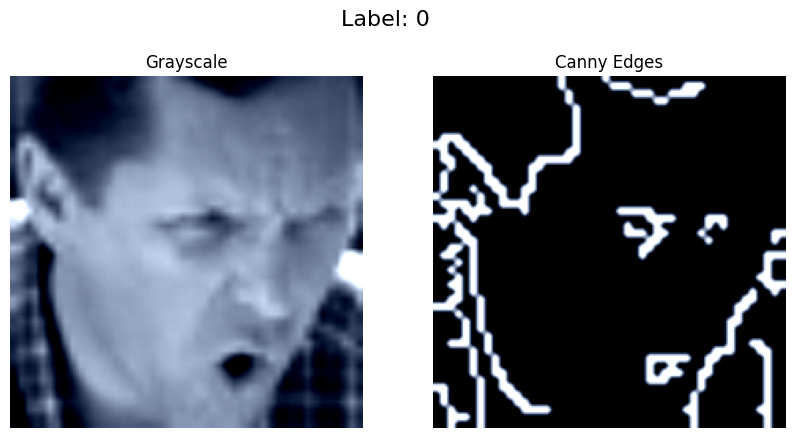

In [ ]:
# --- Visualization of Grayscale and Canny for a sample ---
sample_img, sample_label = train_dataset[0]  # [2, 3, H, W], label

print("Sample tensor shape:", sample_img.shape)  # Expect [2, 3, H, W]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
titles = ["Grayscale", "Canny Edges"]

for i in range(2):
    # Convert tensor to numpy for plotting
    img_np = sample_img[i].cpu().permute(1, 2, 0).numpy()  # [H, W, C]
    img_np = (img_np * 0.5) + 0.5  # Denormalize from [-1,1] -> [0,1]
    axs[i].imshow(img_np)
    axs[i].axis('off')
    axs[i].set_title(titles[i])

plt.suptitle(f"Label: {sample_label}", fontsize=16)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# --------------------------- #
# 🧩 Basic Residual Convolution Block
# --------------------------- #
class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(self.bn2(self.conv2(out)))
        out += self.shortcut(x)
        return F.relu(out)

# --------------------------- #
# 🧠 Local Feature Extractor
# --------------------------- #
class LocalFeatureExtractor(nn.Module):
    def __init__(self, in_channels=3, base_channels=32, dropout=0.5):
        super().__init__()
        self.layer1 = ResidualConvBlock(in_channels, base_channels)
        self.layer2 = ResidualConvBlock(base_channels, base_channels*2)
        self.layer3 = ResidualConvBlock(base_channels*2, base_channels*4)
        self.layer4 = ResidualConvBlock(base_channels*4, base_channels*8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(base_channels*8, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)  # [B, 128]

# --------------------------- #
# 🌍 Global Feature Extractor
# --------------------------- #
class GlobalFeatureExtractor(nn.Module):
    def __init__(self, output_dim=256, dropout=0.3, use_pretrained=True):
        super().__init__()
        self.resnet = models.resnet50(weights=(models.ResNet50_Weights.IMAGENET1K_V2 if use_pretrained else None))
        self.resnet_features = nn.Sequential(*list(self.resnet.children())[:-2])
        self.efficient = models.efficientnet_b0(weights=(models.EfficientNet_B0_Weights.IMAGENET1K_V1 if use_pretrained else None))
        self.efficient_features = nn.Sequential(*list(self.efficient.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        fuse_in = 2048 + 1280
        self.fc = nn.Sequential(
            nn.Linear(fuse_in, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        r = self.resnet_features(x)
        e = self.efficient_features(x)
        r_pool = self.pool(r).flatten(1)
        e_pool = self.pool(e).flatten(1)
        combined = torch.cat([r_pool, e_pool], dim=1)
        return self.fc(combined)  # [B, output_dim]

# --------------------------- #
# 🔗 Fusion of Local + Global
# --------------------------- #
class FeatureFusion(nn.Module):
    def __init__(self, local_dim=128, global_dim=256, fused_dim=128, dropout=0.5):
        super().__init__()
        self.local_fc = nn.Linear(local_dim, fused_dim)
        self.global_fc = nn.Linear(global_dim, fused_dim)
        self.attn = nn.MultiheadAttention(fused_dim, 4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(fused_dim)
        self.mlp = nn.Sequential(
            nn.Linear(fused_dim, fused_dim*2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fused_dim*2, fused_dim)
        )
    def forward(self, local_feat, global_feat):
        l = self.local_fc(local_feat)
        g = self.global_fc(global_feat)
        x = torch.stack([l, g], dim=1)
        attn_out, _ = self.attn(x, x, x)
        x = self.norm(x + attn_out)
        x = x + self.mlp(x)
        return x.view(x.size(0), -1)

# --------------------------- #
# ⏱️ Temporal Model
# --------------------------- #
class TemporalFusion(nn.Module):
    def __init__(self, embed_dim=128, num_layers=2, num_heads=4, dropout=0.5):
        super().__init__()
        self.gru = nn.GRU(embed_dim, embed_dim//2, batch_first=True, bidirectional=True)
        layer = nn.TransformerEncoderLayer(embed_dim, num_heads, dim_feedforward=256, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers)
        self.temporal_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.transformer(out)
        attn_out, _ = self.temporal_attn(out, out, out)
        return self.norm(out + attn_out)

# --------------------------- #
# 🎯 Multihead Attention Pooling
# --------------------------- #
class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.output_proj = nn.Linear(embed_dim*2, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        B, T, D = x.shape
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attn = torch.softmax(Q @ K.transpose(-2,-1) / (D**0.5), dim=-1)
        x = attn @ V
        mean = x.mean(1)
        max_, _ = x.max(1)
        out = torch.cat([mean, max_], dim=1)
        return self.norm(self.output_proj(out))

# --------------------------- #
# ❤️ Advanced Emotion Recognition Model
# --------------------------- #
class AdvancedEmotionRecognitionModel(nn.Module):
    def __init__(self, num_emotions=7, use_valence_arousal=True, use_AU=True, dropout=0.5):
        super().__init__()
        self.local_extractor = LocalFeatureExtractor(in_channels=3, base_channels=32, dropout=dropout)
        self.global_extractor = GlobalFeatureExtractor(output_dim=256, dropout=dropout)
        fused_dim = 128
        self.fusion = FeatureFusion(local_dim=128, global_dim=256, fused_dim=fused_dim, dropout=dropout)
        temporal_embed_dim = 128
        self.temporal_proj = nn.Linear(2*fused_dim, temporal_embed_dim)
        self.temporal = TemporalFusion(embed_dim=temporal_embed_dim, num_layers=2, num_heads=4, dropout=dropout)
        self.attn_pool = MultiHeadAttentionPooling(embed_dim=temporal_embed_dim, num_heads=4)
        self.emotion_head = nn.Sequential(
            nn.Linear(temporal_embed_dim, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_emotions)
        )
        if use_valence_arousal:
            self.va_head = nn.Sequential(
                nn.Linear(temporal_embed_dim, 32),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(32, 2),
                nn.Tanh()
            )
        if use_AU:
            self.au_head = nn.Sequential(
                nn.Linear(temporal_embed_dim, 32),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(32, 17),
                nn.Sigmoid()
            )
    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        local_feats = self.local_extractor(x)
        global_feats = self.global_extractor(x)
        fused = self.fusion(local_feats, global_feats)
        fused = fused.view(B, T, -1)
        fused = self.temporal_proj(fused)
        temporal_feats = self.temporal(fused)
        pooled = self.attn_pool(temporal_feats)
        outputs = {"emotion": self.emotion_head(pooled)}
        if hasattr(self, "va_head"):
            outputs["valence_arousal"] = self.va_head(pooled)
        if hasattr(self, "au_head"):
            outputs["AU"] = self.au_head(pooled)
        return outputs


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedEmotionRecognitionModel(num_emotions=8).to(device)

In [ ]:
from torch.cuda.amp import GradScaler
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scaler = GradScaler()


/tmp/ipython-input-2705205709.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
import torch
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import os

# ====== Training Function ======
def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type):  # updated syntax
            outputs = model(images)
            loss = criterion(outputs["emotion"], labels)  # FIXED dict issue

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        _, predicted = outputs["emotion"].max(1)  # FIXED
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy


# ====== Validation Function ======
def validate(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type=device.type):  # updated syntax
                outputs = model(images)
                loss = criterion(outputs["emotion"], labels)  # FIXED

            val_loss += loss.item() * labels.size(0)
            _, predicted = outputs["emotion"].max(1)  # FIXED
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = val_loss / total
    accuracy = correct / total
    return epoch_loss, accuracy




In [ ]:
start_epoch = 0
best_val_acc = 0.0

if os.path.exists(save_path):
    print("🔄 Loading checkpoint...")
    checkpoint = torch.load(save_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_acc = checkpoint['val_acc']
    print(f"Resumed from epoch {start_epoch}, best val acc: {best_val_acc:.4f}")


🔄 Loading checkpoint...
Resumed from epoch 6, best val acc: 0.8191


In [ ]:
# --- Training loop ---
for epoch in range(start_epoch, EPOCHS):
    print(f"\n🌟 Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_acc = validate(model, test_loader, criterion, device)  # scaler removed

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val    Loss: {val_loss:.4f} | Val    Acc: {val_acc:.4f}")

    # --- Save checkpoint if improved ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'val_acc': best_val_acc
        },save_path)
        print("✅ Saved new best checkpoint!")

print("\nTraining Complete.")


🌟 Epoch 7/70


Train Loss: 0.4398 | Train Acc: 0.8733
Val    Loss: 0.6430 | Val    Acc: 0.8138

🌟 Epoch 8/70


Training:  44%|████▎     | 774/1775 [17:24<22:26,  1.35s/it]